<h1 style="color:#1565C0;">Day 4 - Descriptive Statistics</h1>

In this notebook, descriptive statistics are applied to a real vehicle dataset to understand its distribution and identify abnormal observations before any further analysis.

<h2 style="color:#1976D2;">Task 1 - Load and Explore the Dataset</h2>

The first step is loading the dataset, selecting the required columns, and inspecting the data structure before starting the statistical analysis.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv("../../week1/day4/exp1_14drivers_14cars_dailyRoutes.csv")
col = ["MARK" , "MODEL" , "CAR_YEAR" , "SPEED" ,"ENGINE_COOLANT_TEMP" , "ENGINE_RPM" , "AIR_INTAKE_TEMP"]
cars = data[col].copy()
print(cars.head())
print(cars.info())
speed = cars["SPEED"]

        MARK  MODEL  CAR_YEAR  SPEED  ENGINE_COOLANT_TEMP  ENGINE_RPM  \
0  chevrolet  agile    2011.0    0.0                 80.0      1009.0   
1  chevrolet  agile    2011.0    0.0                 80.0      1003.0   
2  chevrolet  agile    2011.0    0.0                 80.0       995.0   
3  chevrolet  agile    2011.0    0.0                 80.0      1004.0   
4  chevrolet  agile    2011.0    0.0                 80.0      1005.0   

   AIR_INTAKE_TEMP  
0             59.0  
1             59.0  
2             59.0  
3             60.0  
4             60.0  
<class 'pandas.DataFrame'>
RangeIndex: 47514 entries, 0 to 47513
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   MARK                 47459 non-null  str    
 1   MODEL                47459 non-null  str    
 2   CAR_YEAR             47459 non-null  float64
 3   SPEED                46529 non-null  float64
 4   ENGINE_COOLANT_TEMP  33964 non-nu

/tmp/ipykernel_252516/2520136328.py:4: DtypeWarning: Columns (0: FUEL_LEVEL, 1: MAF, 2: ENGINE_RUNTIME, 3: TROUBLE_CODES, 4: EQUIV_RATIO) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("../../week1/day4/exp1_14drivers_14cars_dailyRoutes.csv")


<h2 style="color:#F57C00;">Observation</h2>

The dataset contains both categorical and numerical features. For this analysis, the SPEED column is selected because it is suitable for applying descriptive statistics.


<h2 style="color:#1976D2;">Task 2 - Compute Descriptive Statistics</h2>

This task calculates the main statistical measures for the vehicle speed column to better understand its center and variability.

In [9]:
avg = speed.mean()
mid = speed.median()
std = speed.std()
var = speed.var()
q1 , q3 = np.nanpercentile(speed , [25 , 75])
iqr = q3 - q1

# Statistics Included 
- Mean
- Median
- Variance
- Standard Deviation
- First Quartile (Q1)
- Third Quartile (Q3)
- Interquartile Range (IQR)

In [10]:
print(f"Mean = {avg}")
print(f"Median = {mid}")
print(f"Standard Deviation = {std}")
print(f"Variance =  {var}")
print(f"Q1 = {q1}")
print(f"Q3 = {q3}")
print(f"IQR = {iqr}")

Mean = 24.743751208923467
Median = 14.0
Standard Deviation = 29.294017093082225
Variance =  858.1394374497935
Q1 = 0.0
Q3 = 42.0
IQR = 42.0


<h2 style="color:#F57C00;">Observation</h2>

The mean is higher than the median, indicating that the distribution is influenced by larger speed values. The median provides a better representation of the typical vehicle speed.

<h2 style="color:#1976D2;">Task 3 - Detect Outliers Using the IQR Rule</h2>

The Interquartile Range (IQR) is used to compute the acceptable range of values. Any speed outside this interval is considered a potential outlier.

In [11]:
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)
filtiered_cars = cars[(cars["SPEED"] >= lower_bound) & (cars["SPEED"] <= upper_bound)]

<h2 style="color:#388E3C;">Result</h2>

The dataset has been filtered using the calculated lower and upper bounds. The remaining records are considered valid for further analysis.

In [12]:
print(filtiered_cars.shape)
print(f"Mean = {avg}")
print(f"Median = {mid}")
print(f"Standard Deviation = {std}")
print(f"Variance =  {var}")
print(f"Q1 = {q1}")
print(f"Q3 = {q3}")
print(f"IQR = {iqr}")
print(f"Lower Bound = {lower_bound}")
print(f"Upper Bound = {upper_bound}")



(45785, 7)
Mean = 24.743751208923467
Median = 14.0
Standard Deviation = 29.294017093082225
Variance =  858.1394374497935
Q1 = 0.0
Q3 = 42.0
IQR = 42.0
Lower Bound = -63.0
Upper Bound = 105.0


<h2 style="color:#1976D2;">Task 4 - Compare the Dataset Before and After Filtering</h2>

Comparing the dataset before and after removing outliers helps evaluate how extreme observations affect the statistical measures.

In [13]:
clean_speed = filtiered_cars["SPEED"]

print("Before cleaning")
print(speed.describe())
print("After Cleaning")
print(clean_speed.describe())

Before cleaning
count    46529.000000
mean        24.743751
std         29.294017
min          0.000000
25%          0.000000
50%         14.000000
75%         42.000000
max        143.000000
Name: SPEED, dtype: float64
After Cleaning
count    45785.000000
mean        23.265764
std         27.098246
min          0.000000
25%          0.000000
50%         13.000000
75%         41.000000
max        105.000000
Name: SPEED, dtype: float64


<h2 style="color:#7B1FA2;">Discussion</h2>

Removing outliers reduces the influence of extreme values and produces statistics that better describe the majority of the observations.

<h2 style="color:#1976D2;">Task 5 - Visualize the Distribution</h2>

Visualizing the data provides a clearer understanding of its distribution and highlights potential outliers.

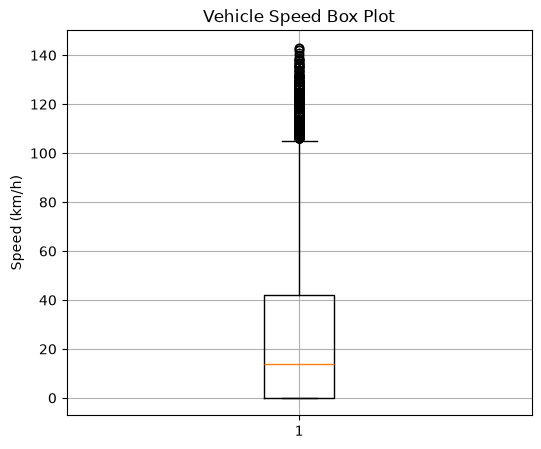

In [14]:
plt.figure(figsize=(6,5))
plt.boxplot(speed.dropna())
plt.title("Vehicle Speed Box Plot")
plt.ylabel("Speed (km/h)")
plt.grid(True)
plt.show()


<h2 style="color:#D32F2F;">Conclusion</h2>

The descriptive statistics and the box plot provide a clear understanding of the vehicle speed distribution.

The IQR successfully identifies abnormal observations, making the dataset more reliable for future analysis after filtering these values.